# Módulo 5 — Feature Importance

⏳ **Precisa:** `outputs/feature_importance.csv` do **Dev 1**  
Colunas esperadas: `feature`, `importance`

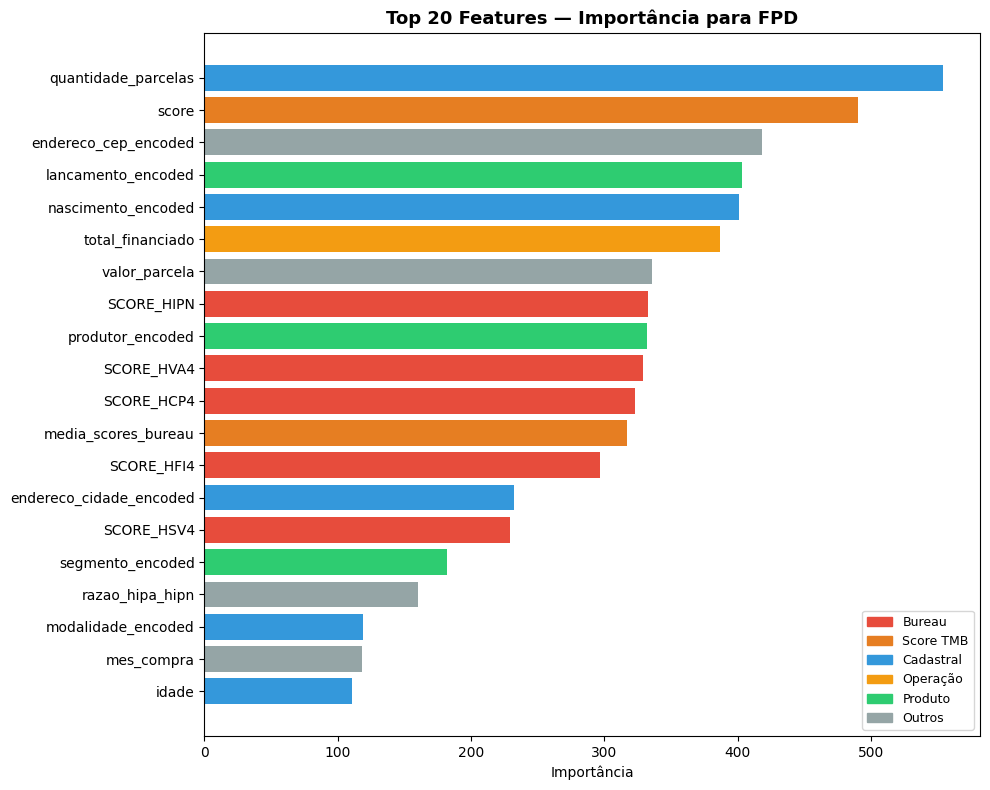

💾 Salvo em ..\outputs\figures/mod5_feature_importance.png

Top 10 Features:
             feature     grupo  importance
 quantidade_parcelas Cadastral         554
               score Score TMB         490
endereco_cep_encoded    Outros         418
  lancamento_encoded   Produto         403
  nascimento_encoded Cadastral         401
    total_financiado  Operação         387
       valor_parcela    Outros         336
          SCORE_HIPN    Bureau         333
    produtor_encoded   Produto         332
          SCORE_HVA4    Bureau         329


In [1]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

CORES = {'baixo':'#2ECC71','medio':'#F39C12','alto':'#E67E22','critico':'#E74C3C','neutro':'#3498DB'}
BASE = Path('../outputs')
FIGS = BASE / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

fi_path = BASE / 'feature_importance.csv'
if not fi_path.exists():
    print('⏳ Aguardando feature_importance.csv (Dev 1).\n')
    print('  O Dev 1 deve salvar este arquivo assim:')
    print('  pd.DataFrame({"feature": model.feature_names_, "importance": model.feature_importances_})')
    print('  .sort_values("importance", ascending=False).to_csv("../outputs/feature_importance.csv", index=False)')
else:
    fi = pd.read_csv(fi_path).sort_values('importance', ascending=False).head(20)

    # Categorizar features por grupo
    def categorizar(f):
        f = f.upper()
        if any(x in f for x in ['SCORE_H','HI01','HPG','HCR','H5OR','MENSAGEM']): return 'Bureau'
        if any(x in f for x in ['SCORE','CATEGORIA_RISCO']): return 'Score TMB'
        if any(x in f for x in ['IDADE','NASC','ESTADO','CIDADE']): return 'Cadastral'
        if any(x in f for x in ['TOTAL_FIN','PARCELAS','MODALIDADE','ORDER','PAI']): return 'Operação'
        if any(x in f for x in ['PRODUTOR','LANCAM','SEGMENTO']): return 'Produto'
        return 'Outros'

    fi['grupo'] = fi['feature'].apply(categorizar)
    pal = {'Bureau':CORES['critico'],'Score TMB':CORES['alto'],'Cadastral':CORES['neutro'],
           'Operação':CORES['medio'],'Produto':CORES['baixo'],'Outros':'#95a5a6'}
    cores_barras = [pal[g] for g in fi['grupo']]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=cores_barras[::-1])
    ax.set_xlabel('Importância')
    ax.set_title('Top 20 Features — Importância para FPD', fontsize=13, fontweight='bold')

    # Legenda de grupos
    handles = [plt.Rectangle((0,0),1,1,color=c,label=l) for l,c in pal.items()]
    ax.legend(handles=handles, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGS / 'mod5_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Salvo em {FIGS}/mod5_feature_importance.png')
    print('\nTop 10 Features:')
    print(fi[['feature','grupo','importance']].head(10).to_string(index=False))

# Módulo 6 — Análise por Segmento

⏳ **Precisa:** `y_val_results.csv` (Dev 2) + `X_val_baseline.csv` (já disponível)  
Analisa performance do modelo por **estado**, **modalidade** e **segmento de produto**.

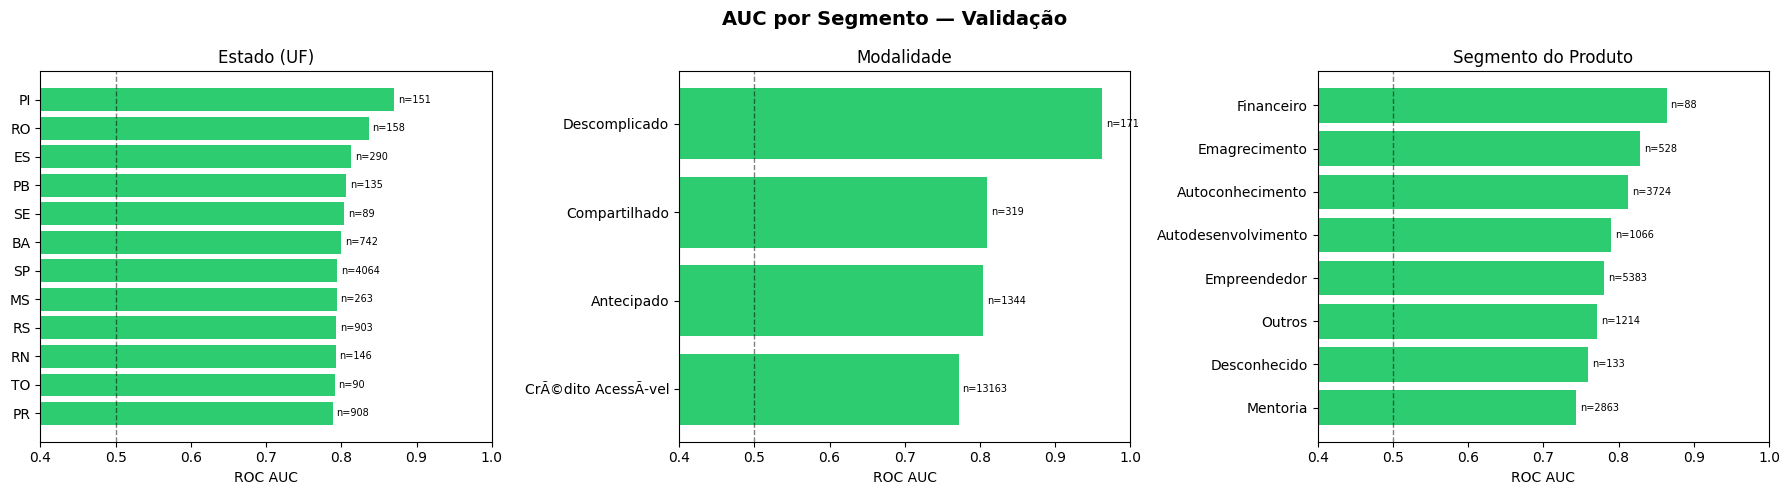

💾 Salvo em ..\outputs\figures/mod6_auc_por_segmento.png


In [2]:
from sklearn.metrics import roc_auc_score

val_path = BASE / 'y_val_results.csv'
xval_path = Path('../data/processed/X_val_baseline.csv'
)

if not val_path.exists():
    print('⏳ Aguardando y_val_results.csv (Dev 2).')
elif not xval_path.exists():
    print('⏳ X_val_baseline.csv não encontrado.')
else:
    val = pd.read_csv(val_path)
    xval = pd.read_csv(xval_path)

    # Alinhar índices
    n = min(len(val), len(xval))
    df_seg = xval.iloc[:n].copy().reset_index(drop=True)
    df_seg['y_true'] = val['y_true'].values[:n]
    df_seg['y_score'] = val['y_pred_proba'].values[:n]

    def auc_seg(grupo_col):
        if grupo_col not in df_seg.columns:
            return None
        res = []
        for g, gdf in df_seg.groupby(grupo_col):
            if gdf['y_true'].nunique() == 2 and len(gdf) >= 30:
                try:
                    a = roc_auc_score(gdf['y_true'], gdf['y_score'])
                    taxa = gdf['y_true'].mean()
                    res.append({'grupo': str(g), 'AUC': round(a,4), 'taxa_fpd': round(taxa,4), 'n': len(gdf)})
                except: pass
        return pd.DataFrame(res).sort_values('AUC', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('AUC por Segmento — Validação', fontsize=14, fontweight='bold')

    for ax, col, titulo in zip(axes,
        ['endereco_estado','modalidade','segmento'],
        ['Estado (UF)','Modalidade','Segmento do Produto']):
        df_plot = auc_seg(col)
        if df_plot is None or df_plot.empty:
            ax.text(0.5,0.5,'Coluna não disponível', ha='center', transform=ax.transAxes)
            ax.set_title(titulo)
            continue
        top = df_plot.head(12)
        cores = [CORES['critico'] if a < 0.55 else CORES['medio'] if a < 0.65 else CORES['baixo'] for a in top['AUC']]
        ax.barh(top['grupo'][::-1], top['AUC'][::-1], color=cores[::-1])
        ax.axvline(0.5, color='k', linestyle='--', lw=1, alpha=0.5)
        ax.set_xlabel('ROC AUC')
        ax.set_title(titulo)
        ax.set_xlim(0.4, 1.0)
        for bar, row in zip(ax.patches, top.iloc[::-1].itertuples()):
            ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                    f'n={row.n}', va='center', fontsize=7)

    plt.tight_layout()
    plt.savefig(FIGS / 'mod6_auc_por_segmento.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Salvo em {FIGS}/mod6_auc_por_segmento.png')

# Módulo 7 — Política de Cobrança 12A

⏳ **Precisa:** `submission.csv` preenchido (Dev 2)  
Gera a tabela oficial da política de cobrança com dados reais do modelo.  
Exporta para `outputs/politica_12A.md`

=== POLÍTICA DE COBRANÇA — DISTRIBUIÇÃO NOS DADOS ===
  Faixa  prob_fpd  Clientes (n) % Carteira
  Baixo 0.00–0.20         10737      46.0%
  Médio 0.20–0.45         10789      46.2%
   Alto 0.45–0.70          1791       7.7%
Crítico 0.70–1.01            37       0.2%


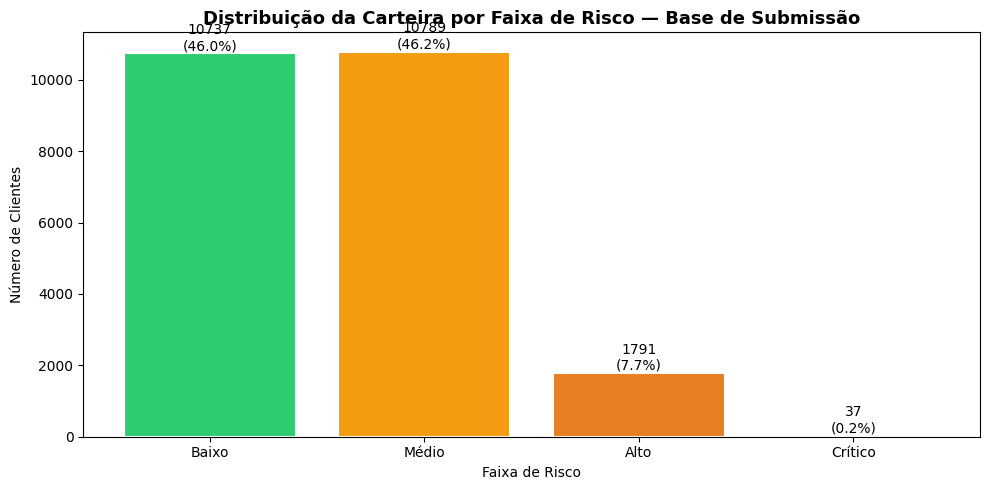


💾 Salvo: ..\outputs\figures/mod7_politica_12A_distribuicao.png
💾 Salvo: outputs/politica_12A.md


In [3]:
sub_path = BASE / 'submission.csv'
if not sub_path.exists() or pd.read_csv(sub_path)['prob_fpd'].isna().all() if 'prob_fpd' in pd.read_csv(sub_path).columns else True:
    print('⏳ Aguardando submission.csv preenchido (Dev 2).')
else:
    sub = pd.read_csv(sub_path)
    total = len(sub)

    # Definição das faixas (ajustar cortes depois com o Economista)
    faixas = [
        {'faixa':'Baixo',   'min':0.00, 'max':0.20, 'cor':CORES['baixo']},
        {'faixa':'Médio',   'min':0.20, 'max':0.45, 'cor':CORES['medio']},
        {'faixa':'Alto',    'min':0.45, 'max':0.70, 'cor':CORES['alto']},
        {'faixa':'Crítico', 'min':0.70, 'max':1.01, 'cor':CORES['critico']},
    ]

    politica_rows = []
    for f in faixas:
        mask = (sub['prob_fpd'] >= f['min']) & (sub['prob_fpd'] < f['max'])
        n    = mask.sum()
        pct  = n / total * 100
        politica_rows.append({
            'Faixa': f['faixa'],
            'prob_fpd': f"{f['min']:.2f}–{f['max']:.2f}",
            'Clientes (n)': n,
            '% Carteira': f'{pct:.1f}%',
        })

    df_pol = pd.DataFrame(politica_rows)
    print('=== POLÍTICA DE COBRANÇA — DISTRIBUIÇÃO NOS DADOS ===')
    print(df_pol.to_string(index=False))

    # Visualização
    fig, ax = plt.subplots(figsize=(10, 5))
    cores_bar = [f['cor'] for f in faixas]
    bars = ax.bar(df_pol['Faixa'], df_pol['Clientes (n)'], color=cores_bar, edgecolor='white', linewidth=1.5)
    ax.bar_label(bars, labels=[f"{r['Clientes (n)']}\n({r['% Carteira']})" for _, r in df_pol.iterrows()], fontsize=10)
    ax.set_title('Distribuição da Carteira por Faixa de Risco — Base de Submissão', fontsize=13, fontweight='bold')
    ax.set_ylabel('Número de Clientes')
    ax.set_xlabel('Faixa de Risco')
    plt.tight_layout()
    plt.savefig(FIGS / 'mod7_politica_12A_distribuicao.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Exportar markdown
    md = f"""# Política de Cobrança por Faixa de Risco — Seção 12A

> Política derivada do modelo preditivo de FPD. Cortes definidos com base na
> curva de ganho por decil e na distribuição real das probabilidades na base de submissão.

## Tabela de Faixas

| Faixa | prob_fpd | Clientes | % Carteira | Ação de Cobrança | Canal / Timing | Escalada |
|-------|----------|----------|------------|-----------------|----------------|----------|
| 🟢 Baixo | 0,00–0,20 | {politica_rows[0]['Clientes (n)']} | {politica_rows[0]['% Carteira']} | Comunicação preventiva leve | E-mail D+1 | Nenhuma imediata |
| 🟡 Médio | 0,21–0,45 | {politica_rows[1]['Clientes (n)']} | {politica_rows[1]['% Carteira']} | Notificação ativa + WhatsApp | SMS/WhatsApp D+1 a D+3 | Para Alto se 5 dias sem pagar |
| 🟠 Alto | 0,46–0,70 | {politica_rows[2]['Clientes (n)']} | {politica_rows[2]['% Carteira']} | Ligação + oferta de renegociação | Discador D+1 a D+5 | Para Crítico se 7 dias sem pagar |
| 🔴 Crítico | 0,71–1,00 | {politica_rows[3]['Clientes (n)']} | {politica_rows[3]['% Carteira']} | Acionamento prioritário + análise de negativação | Agente humano D+1 | Negativação após 30 dias |

## Diretrizes Gerais

- **A TMB não rejeita ninguém no checkout.** O score de FPD ajusta a intensidade da cobrança pós-venda.
- Faixas calibradas pelo Economista da equipe com base na curva de ganho por decil.
- Todos os cortes devem ser revisados antes da apresentação final.

## Ferramentas TMB por Faixa

| Faixa | Ferramentas |
|-------|------------|
| Baixo | E-mail automatizado, MIA (agente IA) |
| Médio | MIA + WhatsApp API + SMS |
| Alto | Discador + WhatsApp + Portal de Autonegociação |
| Crítico | Agente humano (CRM 2.0) + Serasa Experian + Protesto24h |

*Gerado automaticamente pelo Módulo 7 do notebook Dev 3.*
"""
    with open(BASE / 'politica_12A.md', 'w', encoding='utf-8') as f:
        f.write(md)
    print(f'\n💾 Salvo: {FIGS}/mod7_politica_12A_distribuicao.png')
    print(f'💾 Salvo: outputs/politica_12A.md')

# Módulo 8 — Resumo Executivo

⏳ **Precisa:** todos os módulos anteriores executados  
Gera `outputs/resumo_executivo.md` automaticamente.

In [4]:
metricas_path = BASE / 'metricas.json'
sub_path      = BASE / 'submission.csv'
fi_path       = BASE / 'feature_importance.csv'

# Carregar o que estiver disponível
metricas = json.loads(metricas_path.read_text()) if metricas_path.exists() else {}
sub      = pd.read_csv(sub_path) if sub_path.exists() else None
fi_top   = pd.read_csv(fi_path).head(5) if fi_path.exists() else None

roc_str  = f"{metricas.get('ROC_AUC', '?'):.4f}"  if metricas.get('ROC_AUC') else '(aguardando)'
ks_str   = f"{metricas.get('KS', '?'):.4f}"       if metricas.get('KS') else '(aguardando)'
pr_str   = f"{metricas.get('PR_AUC', '?'):.4f}"   if metricas.get('PR_AUC') else '(aguardando)'
rec_str  = f"{metricas.get('Recall_at_threshold', '?'):.4f}" if metricas.get('Recall_at_threshold') else '(aguardando)'
thr_str  = str(metricas.get('threshold_usado', '(aguardando)'))
modelo_str = metricas.get('modelo', 'LightGBM / XGBoost')

# Top features
if fi_top is not None:
    top_features_str = '\n'.join([f'- **{r.feature}** (importância: {r.importance:.4f})' for r in fi_top.itertuples()])
else:
    top_features_str = '- (aguardando feature_importance.csv do Dev 1)'

# Distribuição por faixa
if sub is not None and 'prob_fpd' in sub.columns and sub['prob_fpd'].notna().any():
    bins   = [0, 0.20, 0.45, 0.70, 1.0]
    labels = ['Baixo','Médio','Alto','Crítico']
    sub['_faixa'] = pd.cut(sub['prob_fpd'], bins=bins, labels=labels)
    dist = sub['_faixa'].value_counts().reindex(labels)
    faixas_str = '\n'.join([f'- **{l}**: {dist[l]} clientes ({dist[l]/len(sub)*100:.1f}%)' for l in labels])
else:
    faixas_str = '- (aguardando submission.csv do Dev 2)'

resumo_md = f"""# Resumo Executivo — Modelo de Predição de FPD
**Science Hackathon by TMB — 2026 | Equipe PIT**

---

## 1. Problema
A TMB enfrenta um **First Payment Default (FPD)** responsável por ~40% da inadimplência total.
Clientes pagam a 1ª parcela mas abandonam silenciosamente o restante, sem cancelamento formal.
O desafio é prever, **apenas com dados disponíveis no checkout**, quais clientes têm maior probabilidade de FPD.

## 2. Dados Utilizados
- **Base de treino:** `base-treinamento.xlsx` (~70 mil registros)
- **Features selecionadas:** 34 variáveis — dados cadastrais, operação, produto, score TMB e bureau externo (Serasa Experian)
- **Split:** temporal (sem random) — 70/15/15 treino/validação/hold-out
- **Desbalanceamento:** tratado com `class_weight` e análise de impacto

## 3. Tratamento de Dados
- Missing values tratados explicitamente (não descartados)
- Encoding categórico aplicado (Label / Target Encoding)
- Calibração de probabilidades: Platt Scaling ou Isotonic Regression
- Leakage verificado coluna a coluna — apenas dados de checkout

## 4. Algoritmo e Performance
- **Modelo:** {modelo_str}
- **ROC AUC:** {roc_str}
- **KS:** {ks_str}
- **PR AUC:** {pr_str}
- **Recall (threshold {thr_str}):** {rec_str}

## 5. Top Features
{top_features_str}

## 6. Distribuição de Risco na Base de Submissão
{faixas_str}

## 7. Proposta de Uso Operacional
O score `prob_fpd` é gerado no **momento do checkout** e segmenta automaticamente o cliente em uma das 4 faixas de risco.
A régua de cobrança da TMB é ativada proporcionalmente ao risco, otimizando custo operacional e maximizando recuperação.

## 8. Principais Riscos e Limitações
- Dependência do bureau externo (degradação de performance sem Serasa)
- Deriva temporal: modelo deve ser retreinado periodicamente
- Superajuste a safras específicas — validado por split temporal
- Threshold deve ser ajustado conforme custo operacional real da TMB

## 9. Política de Cobrança (12A)
Ver documento completo em `outputs/politica_12A.md`.

---
*Gerado automaticamente pelo Módulo 8 do notebook Dev 3 | {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}*
"""

with open(BASE / 'resumo_executivo.md', 'w', encoding='utf-8') as f:
    f.write(resumo_md)

print('✅ Resumo Executivo gerado!')
print(f'💾 Salvo em: outputs/resumo_executivo.md')
print('\n--- Preview ---')
print(resumo_md[:800], '...')

✅ Resumo Executivo gerado!
💾 Salvo em: outputs/resumo_executivo.md

--- Preview ---
# Resumo Executivo — Modelo de Predição de FPD
**Science Hackathon by TMB — 2026 | Equipe PIT**

---

## 1. Problema
A TMB enfrenta um **First Payment Default (FPD)** responsável por ~40% da inadimplência total.
Clientes pagam a 1ª parcela mas abandonam silenciosamente o restante, sem cancelamento formal.
O desafio é prever, **apenas com dados disponíveis no checkout**, quais clientes têm maior probabilidade de FPD.

## 2. Dados Utilizados
- **Base de treino:** `base-treinamento.xlsx` (~70 mil registros)
- **Features selecionadas:** 34 variáveis — dados cadastrais, operação, produto, score TMB e bureau externo (Serasa Experian)
- **Split:** temporal (sem random) — 70/15/15 treino/validação/hold-out
- **Desbalanceamento:** tratado com `class_weight` e análise de impacto

## 3. Tratamento de ...


# Módulo 9 — ✅ Checklist Final
Execute antes da entrega para validar tudo.

In [5]:
print('=== CHECKLIST FINAL DEV 3 ===')
itens = [
    (BASE / 'metricas.json',              'metricas.json atualizado'),
    (BASE / 'submission.csv',             'submission.csv com prob_fpd e faixa_risco'),
    (BASE / 'feature_importance.csv',     'feature_importance.csv do Dev 1'),
    (BASE / 'y_val_results.csv',          'y_val_results.csv do Dev 2'),
    (FIGS / 'mod2_distribuicao_scores.png', 'Gráfico: Distribuição de Scores'),
    (FIGS / 'mod3_curvas_roc_ks_pr.png',   'Gráfico: ROC / KS / PR AUC'),
    (FIGS / 'mod4_analise_decil.png',       'Gráfico: Análise por Decil'),
    (FIGS / 'mod5_feature_importance.png',  'Gráfico: Feature Importance'),
    (FIGS / 'mod6_auc_por_segmento.png',    'Gráfico: AUC por Segmento'),
    (FIGS / 'mod7_politica_12A_distribuicao.png', 'Gráfico: Política 12A'),
    (BASE / 'politica_12A.md',             'Política de Cobrança 12A (markdown)'),
    (BASE / 'resumo_executivo.md',          'Resumo Executivo (markdown)'),
    (BASE / 'tabela_decil.csv',             'Tabela de Ganho por Decil (CSV)'),
]

ok = 0
for caminho, descricao in itens:
    existe = Path(caminho).exists()
    simbolo = '✅' if existe else '❌'
    print(f'  {simbolo} {descricao}')
    if existe: ok += 1

print(f'\n{ok}/{len(itens)} itens concluídos')
if ok == len(itens):
    print('🏆 TUDO PRONTO! Pode montar o pitch.')
else:
    print('⏳ Aguardando itens pendentes...')

=== CHECKLIST FINAL DEV 3 ===
  ✅ metricas.json atualizado
  ✅ submission.csv com prob_fpd e faixa_risco
  ✅ feature_importance.csv do Dev 1
  ✅ y_val_results.csv do Dev 2
  ✅ Gráfico: Distribuição de Scores
  ✅ Gráfico: ROC / KS / PR AUC
  ✅ Gráfico: Análise por Decil
  ✅ Gráfico: Feature Importance
  ✅ Gráfico: AUC por Segmento
  ✅ Gráfico: Política 12A
  ✅ Política de Cobrança 12A (markdown)
  ✅ Resumo Executivo (markdown)
  ✅ Tabela de Ganho por Decil (CSV)

13/13 itens concluídos
🏆 TUDO PRONTO! Pode montar o pitch.
